In [130]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2

In [131]:
def resize(citra, tinggi_baru, lebar_baru):
    tinggi_asal, lebar_asal = citra.shape[:2]  # :2 agar aman untuk grayscale maupun RGB
    skala_y = tinggi_asal / tinggi_baru
    skala_x = lebar_asal / lebar_baru

    # Cek apakah citra berwarna atau grayscale
    if len(citra.shape) == 3:
        hasil = np.zeros((tinggi_baru, lebar_baru, citra.shape[2]), dtype=np.uint8)
    else:
        hasil = np.zeros((tinggi_baru, lebar_baru), dtype=np.uint8)

    for i in range(tinggi_baru):
        for j in range(lebar_baru):
            y_asal = min(int(i * skala_y), tinggi_asal - 1)
            x_asal = min(int(j * skala_x), lebar_asal - 1)
            hasil[i, j] = citra[y_asal, x_asal]

    return hasil

(np.float64(-0.5), np.float64(1279.5), np.float64(1279.5), np.float64(-0.5))

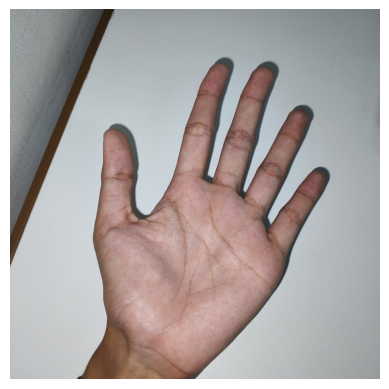

In [132]:
tangan1 = plt.imread("bee.jpeg")

plt.imshow(tangan1)
plt.axis("off")

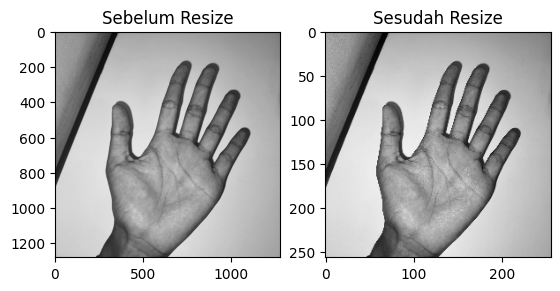

In [133]:
tangan2 = cv2.cvtColor(tangan1, cv2.COLOR_BGR2GRAY)
ukurtangan = resize (tangan1, 256, 256 )
tangan = cv2.cvtColor(ukurtangan, cv2.COLOR_BGR2GRAY)

plt.subplot(1, 2, 1)
plt.title("Sebelum Resize")
plt.imshow(tangan2, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Sesudah Resize")
plt.imshow(tangan, cmap="gray")




In [134]:
def konvolusi(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)

    return canvas

In [135]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

In [136]:
def edge(img, kernelx, kernely):
    gx = konvolusi(img, kernelx)
    gy = konvolusi(img, kernely)

    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)

    return np.clip(canvas, 0, 255).astype(np.uint8)

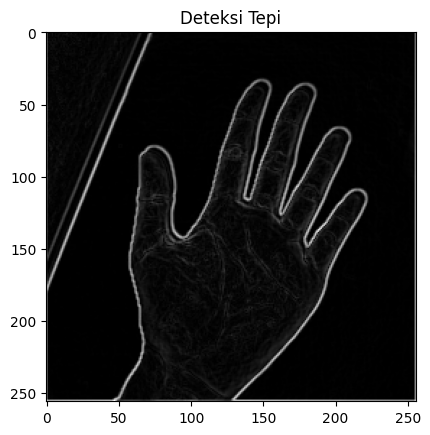

In [137]:
sobel  = edge(tangan,  sobelX, sobelY)
plt.title("Deteksi Tepi")
plt.imshow(sobel, cmap="gray")

In [138]:
def tresh(img, nilai):
    h, w = img.shape
    canvas = np.zeros_like(img, dtype = np.uint8)
    for i in range (h):
        for j in range (w):
            if (img[i, j] > nilai):
                canvas[i, j] = 255
            elif(img[i, j] <= nilai):
                canvas[i,j] = 0
    return canvas

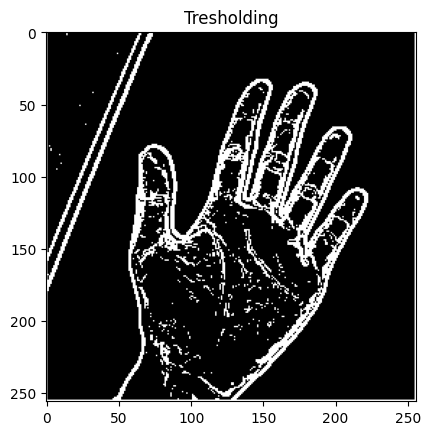

In [139]:
tangantres = tresh (sobel, 20)
plt.title("Tresholding")
plt.imshow(tangantres, cmap="gray")

In [140]:
kernel_diamond = np.array([
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1]
])

kernel_cross = np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
])

kernel_x = np.array([
    [1,0,0,0,1],
    [0,1,0,1,0],
    [0,0,1,0,0],
    [0,1,0,1,0],
    [1,0,0,0,1]
], dtype=np.uint8)

In [141]:
# dilasi
def dilasi(img, kernel):
    h, w = img.shape
    k_h, k_w = kernel.shape

    center = k_h // 2
    hasil = np.zeros((h,w))
    for i  in range(center, h - center):
        for j in range(center, w - center):
            if img[i,j] == 255:
                for k in range (k_h):
                    for l in range (k_w):
                        if (kernel[k,l] == 1):
                            hasil [i + k - center, j + l - center] = 255
            else :
                if hasil[i,j] != 255 :
                    hasil[i,j] = 0
    return hasil

In [142]:
#erosi
def erosi(img, kernel) :
    h, w = img.shape
    k_h, k_w = kernel.shape

    center = k_h // 2
    hasil = np.zeros((h,w))
    for i  in range(center, h - center):
        for j in range(center, w - center):
            cocok = True
            for k in range (k_h):
                for l in range (k_w):
                    if kernel[k,l] == 1 and img[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok :
                    break
            if cocok :
                hasil[i,j] = 255
    return hasil

#opening = erosi + dilasi
#closing = dilasi + erosi
                         

In [143]:
#thinning
def thinning(img):
    biner = (img > 0).astype(np.uint8)
    h, w = biner.shape
    changed = True
    
    while changed :
        changed = False
        hapus = []
        #step 1
        for i in range (1, h-1):
            for j in range (1, w-1):
                p1 = biner[i,j]
                if p1 != 1:
                    continue
                p2 = biner[i-1, j]
                p3 = biner[i-1, j+1]
                p4 = biner[i, j+1]
                p5 = biner[i+1, j+1]
                p6 = biner[i+1, j]
                p7 = biner[i+1, j-1]
                p8 = biner[i, j-1]
                p9 = biner[i-1, j-1]

                tetangga = [p2, p3, p4, p5, p6, p7, p8, p9]
                jmlh = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [p2]

                for k in range(8) :
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1
                
                if (
                    2 <= jmlh <= 6 and
                    transisi == 1 and
                    p2 * p4 * p6 == 0 and
                    p4 * p6 * p8 == 0 
                ) :
                    hapus.append((i,j))
        if hapus :
            changed = True
            for i, j in hapus :
                biner[i,j] = 0
        hapus = []

        #step 2
        for i in range (1, h-1):
            for j in range (1, w-1):
                p1 = biner[i,j]
                if p1 != 1:
                    continue
                p2 = biner[i-1, j]
                p3 = biner[i-1, j+1]
                p4 = biner[i, j+1]
                p5 = biner[i+1, j+1]
                p6 = biner[i+1, j]
                p7 = biner[i+1, j-1]
                p8 = biner[i, j-1]
                p9 = biner[i-1, j-1]

                tetangga = [p2, p3, p4, p5, p6, p7, p8, p9]
                jmlh = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [p2]

                for k in range(8) :
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1
                
                if (
                    2 <= jmlh <= 6 and
                    transisi == 1 and
                    p2 * p4 * p8 == 0 and
                    p2 * p6 * p8 == 0 
                ) :
                    hapus.append((i,j))
        if hapus :
            changed = True
            for i, j in hapus :
                biner[i,j] = 0

    return biner * 255


In [144]:
#thickening
def thickening(img, kernel, iterasi=1) :
    hasil = img.copy()
    for _ in range (iterasi):
        hasil = dilasi(hasil, kernel)
    return hasil

In [145]:
#gradient morph = dilasi - erosi
#pke function
# gradient morphology
def gradient_morph(img, kernel):
    # dilasi - erosi
    hasil_dilasi = dilasi(img, kernel)
    hasil_erosi  = erosi(img, kernel)

    h, w = img.shape
    hasil = np.zeros((h, w))

    for i in range(h):
        for j in range(w):
            selisih = int(hasil_dilasi[i, j]) - int(hasil_erosi[i, j])
            if selisih < 0:
                hasil[i, j] = 0
            elif selisih > 255:
                hasil[i, j] = 255
            else:
                hasil[i, j] = selisih

    return hasil.astype(np.uint8)

#cara cepat
#gradien = np.clip(dilasi(img, kernel).astype(np.int16) - erosi(img, kernel).astype(np.int16), 0, 255).astype(np.uint8)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

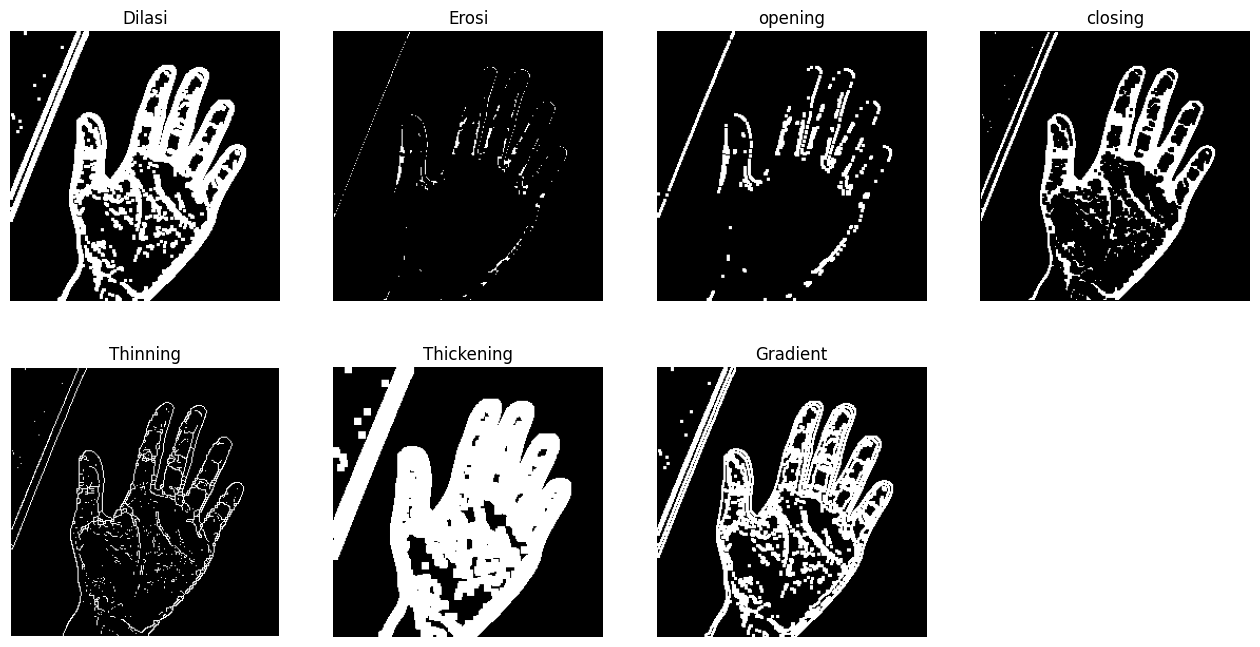

In [146]:
tangandilas = dilasi (tangantres, kernel_cross)
tanganeros = erosi (tangantres, kernel_cross)
tanganopen = dilasi (tanganeros, kernel_cross)
tanganlos = erosi (tangandilas, kernel_cross)
tanganning = thinning (tangantres)
tanganthi = thickening(tangantres, kernel_cross, iterasi=3)
tangangra = gradient_morph (tangantres, kernel_cross)

plt.figure(figsize=(16, 8))
plt.subplot(2, 4, 1)
plt.title("Dilasi")
plt.imshow(tangandilas, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.title("Erosi")
plt.imshow(tanganeros, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.title("opening")
plt.imshow(tanganopen, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.title("closing")
plt.imshow(tanganlos, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.title("Thinning")
plt.imshow(tanganning, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.title("Thickening")
plt.imshow(tanganthi, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.title("Gradient")
plt.imshow(tangangra, cmap="gray")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

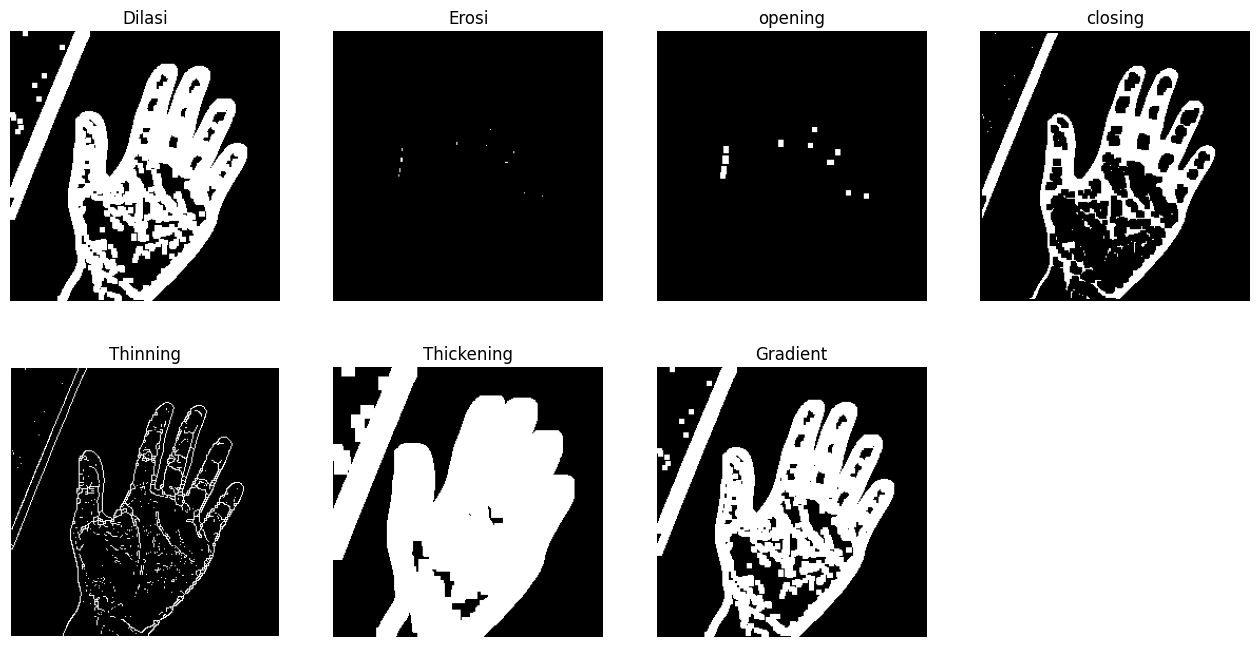

In [147]:
tangandilas1 = dilasi (tangantres, kernel_diamond)
tanganeros1 = erosi (tangantres, kernel_diamond)
tanganopen1 = dilasi (tanganeros1, kernel_diamond)
tanganlos1 = erosi (tangandilas1, kernel_diamond)
tanganning1 = thinning (tangantres)
tanganthi1 = thickening(tangantres, kernel_diamond, iterasi=3)
tangangra1 = gradient_morph (tangantres, kernel_diamond)

plt.figure(figsize=(16, 8))
plt.subplot(2, 4, 1)
plt.title("Dilasi")
plt.imshow(tangandilas1, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.title("Erosi")
plt.imshow(tanganeros1, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.title("opening")
plt.imshow(tanganopen1, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.title("closing")
plt.imshow(tanganlos1, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.title("Thinning")
plt.imshow(tanganning1, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.title("Thickening")
plt.imshow(tanganthi1, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.title("Gradient")
plt.imshow(tangangra1, cmap="gray")
plt.axis("off")

# analisis untuk perbandingan yang 3x3 dan 5x5
hasil untuk 3x3 dengan elemennya bernilai 1 citra hasil morfologi yang dihasilkan masih menampilkan piksel yang tebal sedangkan pada 5x5 pikselnya lebih tipis.

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

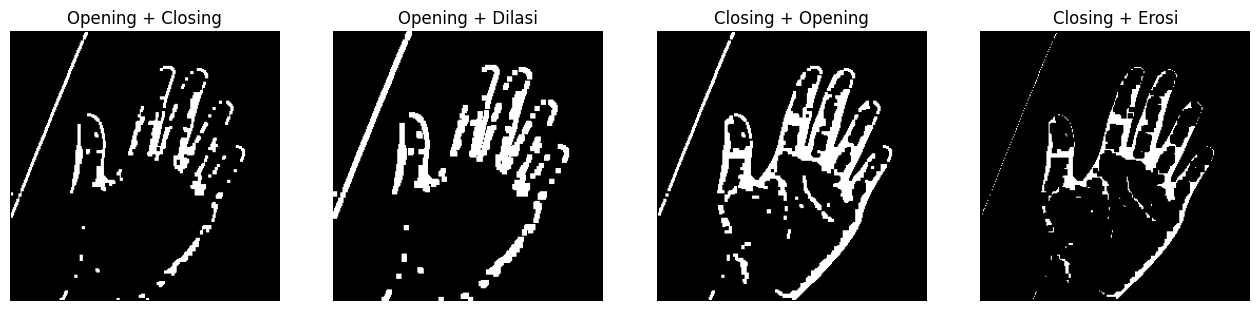

In [150]:
tanganopen2 = dilasi (tanganopen, kernel_cross)
tangabe = erosi (tanganopen2, kernel_cross)

tanganopen3 = dilasi (tanganopen, kernel_cross)

tanganclos2 = erosi (tanganlos, kernel_cross)
tangabe1 = dilasi (tanganclos2, kernel_cross)

tanganbe2 = erosi (tanganlos, kernel_cross)

plt.figure(figsize=(16, 8))
plt.subplot(2, 4, 1)
plt.title("Opening + Closing")
plt.imshow(tangabe, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.title("Opening + Dilasi")
plt.imshow(tanganopen3, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.title("Closing + Opening")
plt.imshow(tangabe1, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.title("Closing + Erosi")
plt.imshow(tanganbe2, cmap="gray")
plt.axis("off")

In [151]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for r in range(size):
                        for c in range(size):
                            total += int(region[r, c])
                    canvas[i, j] = total // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = [0] * (size * size)
                    for r in range(size):
                        for c in range(size):
                            values[r * size + c] = int(region[r, c])

                    n = size * size
                    for x in range(n - 1):
                        for y in range(n - x - 1):
                            if values[y] > values[y + 1]:
                                values[y], values[y + 1] = values[y + 1], values[y]

                    canvas[i, j] = values[n // 2]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val
    return canvas

In [154]:
akhir = thinning (sobel, 20)

plt.subplot(2, 4, 5)
plt.title("Thinning")
plt.imshow(akhir, cmap="gray")
plt.axis("off")

TypeError: thinning() takes 1 positional argument but 2 were given